# 01 — LSA16: del baseline CNN a detección espacial con YOLO

**Trabajo de Investigación — Redes Neuronales 2026-1**  
Universidad Nacional de Quilmes — Departamento de Ciencia y Tecnología

**Autores:** Julián Santiago González Avendaño, Agustín García Smith  
**Directora:** Ing. Roxana Martínez

---

## Resumen

Este notebook documenta el trabajo experimental completo sobre el dataset **LSA16** (16 configuraciones manuales de la Lengua de Señas Argentina) en tres etapas:

1. **Replicación del baseline CNN** del paper Quiroga et al. (2017) ["A Study of Convolutional Architectures for Handshape Recognition applied to Sign Language"](../paper-lsa16-cnn.pdf), que reporta **96.18%** de accuracy para LeNet sobre la versión segmentada del dataset.
2. **Mejoras sobre el CNN**: data augmentation (hipótesis refutada) y transfer learning con ResNet-18 (mejora confirmada, supera al paper).
3. **Detección espacial con YOLOv8** sobre las imágenes completas — **contribución original del trabajo**.

**Hallazgo clave**: en el escenario **realista** (imagen completa, sin preprocesamiento manual), el CNN colapsa a 22.12% mientras YOLO alcanza niveles operativos de ~90% — una gran diferencia cualitativa que valida la hipótesis central del trabajo: para sistemas reales, **la detección espacial es ampliamente superior a la clasificación de imagen entera**.

## 1. Contexto y objetivo

### 1.1. ¿Por qué reconocer LSA?

El reconocimiento automático de Lengua de Señas Argentina (LSA) es un problema de Visión por Computadora con alto valor de accesibilidad para la comunidad sorda. El pipeline completo de SLR (Sign Language Recognition) involucra detección de manos, clasificación de configuraciones, seguimiento temporal y análisis semántico. La calidad de la **clasificación de configuración manual** (*handshape recognition*) es el cuello de botella del pipeline.

### 1.2. Paper de referencia

Quiroga et al. (2017) compararon varias arquitecturas CNN sobre LSA16 y reportaron:

| Método | Accuracy LSA16 |
|---|---:|
| Feedforward (baseline) | 86.58% |
| **LeNet** | **95.78%** |
| All Convolutional | 94.56% |
| VGG16 | 95.92% |
| ResNet-34 | 93.49% |

Y para distintos esquemas de preprocesamiento con LeNet:

| Esquema | Accuracy |
|---|---:|
| Raw (RGB) | 83.54% |
| **Segmented Hand RGB** | **96.18%** |
| Segmented Grayscale | 87.08% |

### 1.3. Objetivos del notebook

1. **Replicar** 96.18% sobre la versión segmentada del dataset usando exactamente la metodología del paper.
2. **Caracterizar honestamente la varianza** del experimento (algo que el paper diluye promediando 100 corridas).
3. **Mejorar el baseline CNN**: data augmentation y transfer learning con ResNet-18.
4. **Implementar y evaluar un detector espacial (YOLOv8)** sobre las imágenes completas, comparándolo cuantitativamente con el baseline CNN.

## 2. Setup del entorno

In [ ]:
import json
import sys
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display, Image as IPImage

# Acceso a src/ desde el notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import CANONICAL_DIR, LSA16_NAMES, RAW_DIR, SEGMENTED_DIR
from src.preprocessing import canonical_align
from src.results_parser import get_cnn_results, get_best_cnn_per_setup, get_yolo_results

print(f'Proyecto raíz: {PROJECT_ROOT}')
print(f'Clases LSA16: {LSA16_NAMES}')

Proyecto raíz: c:\Users\garci\Projects\uni\reder-neuronales-repo
Clases LSA16: ['Five', 'Four', 'Horns', 'Curve', 'Fingers', 'Double', 'Hook', 'Index', 'L', 'Flat', 'Mitten', 'Beak', 'Thumb', 'Fist', 'Telephone', 'V']


## 3. Dataset LSA16

### 3.1. Composición

- **800 imágenes** en total
- **16 clases** (configuraciones manuales más usadas en LSA)
- **10 sujetos** que ejecutaron **5 repeticiones** de cada configuración
- Captura en entorno controlado: fondo blanco, guantes de color fluorescente, iluminación uniforme

El convenio de nombres es `clase_sujeto_repeticion.png` (clase 1-indexed).

In [ ]:
# Distribución del dataset
import glob
from collections import Counter

files = sorted(glob.glob(str(PROJECT_ROOT / 'lsa16_segmented_right_hand' / '*.png')))
classes  = Counter(int(Path(f).name.split('_')[0]) for f in files)
subjects = Counter(int(Path(f).name.split('_')[1]) for f in files)
print(f'Total imágenes: {len(files)}')
print(f'Clases: {len(classes)} (50 imgs c/u)  | Sujetos: {len(subjects)} (80 imgs c/u)')
print()
for cls in sorted(classes):
    print(f'  Clase {cls:2d} ({LSA16_NAMES[cls-1]:10s}): {classes[cls]} imgs')

Total imágenes: 800
Clases: 16 (50 imgs c/u)  | Sujetos: 10 (80 imgs c/u)

  Clase  1 (Five      ): 50 imgs
  Clase  2 (Four      ): 50 imgs
  Clase  3 (Horns     ): 50 imgs
  Clase  4 (Curve     ): 50 imgs
  Clase  5 (Fingers   ): 50 imgs
  Clase  6 (Double    ): 50 imgs
  Clase  7 (Hook      ): 50 imgs
  Clase  8 (Index     ): 50 imgs
  Clase  9 (L         ): 50 imgs
  Clase 10 (Flat      ): 50 imgs
  Clase 11 (Mitten    ): 50 imgs
  Clase 12 (Beak      ): 50 imgs
  Clase 13 (Thumb     ): 50 imgs
  Clase 14 (Fist      ): 50 imgs
  Clase 15 (Telephone ): 50 imgs
  Clase 16 (V         ): 50 imgs


### 3.2. Variantes que tenemos del dataset

1. **`lsa16_raw/`** — imágenes completas 640×480 con la persona y el guante. Es el escenario *no controlado* (más cercano a una webcam real).
2. **`lsa16_segmented_right_hand/`** — la mano derecha recortada y segmentada sobre fondo negro, en tamaño variable (~150×150). Es la versión que el paper usa para el experimento "Segmented Hand RGB".
3. **`lsa16_segmented_canonical/`** — generada por nosotros aplicando el preprocesamiento del paper (alineamiento canónico). 128×128 fijo. Ver sección 4.

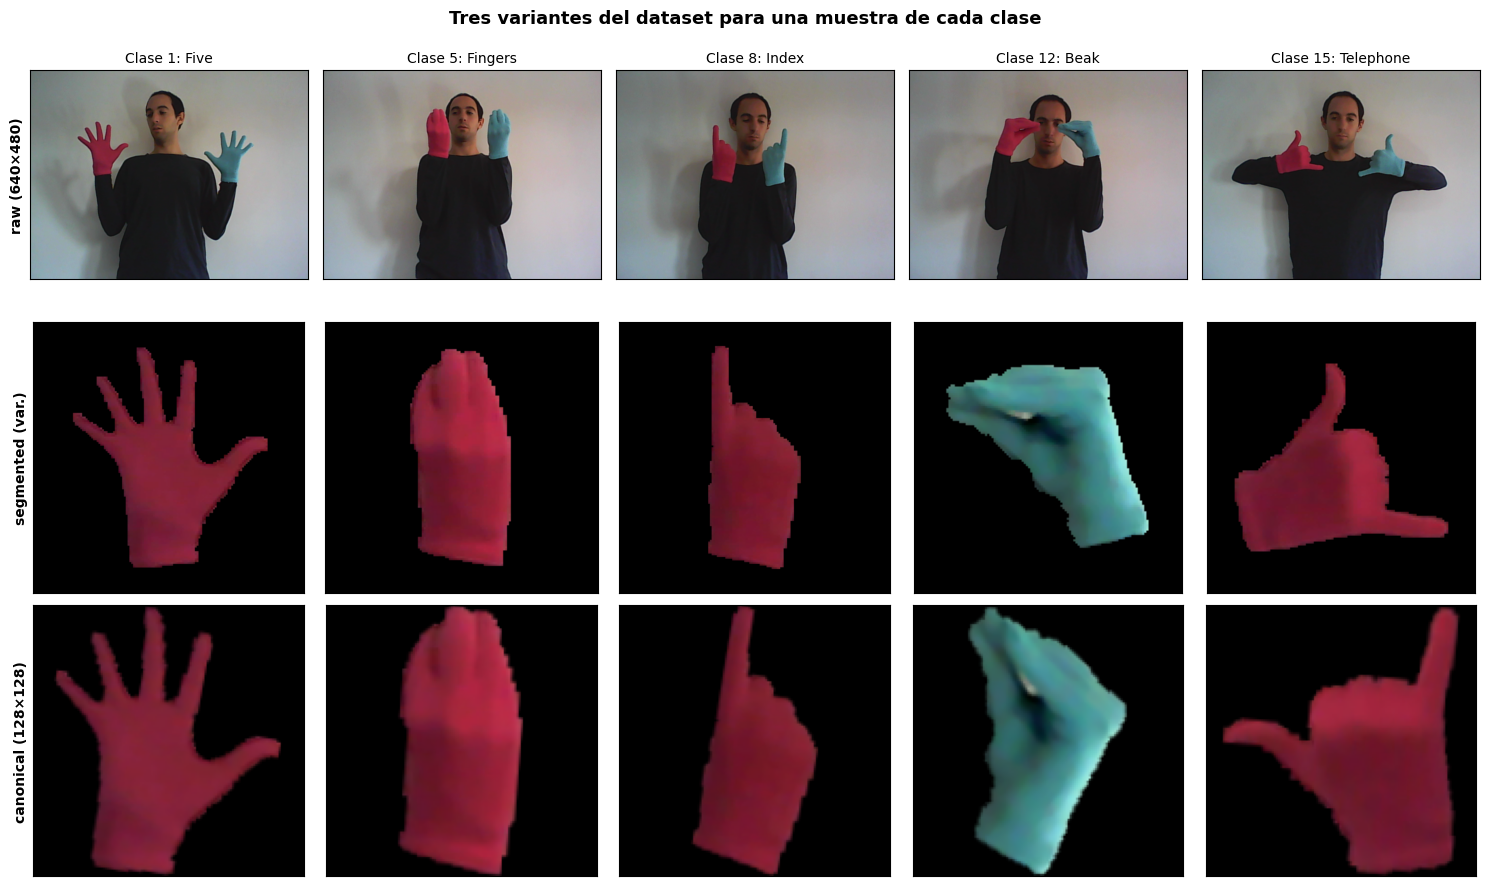

In [ ]:
# Comparación visual de las tres variantes para 5 clases
ejemplos = [(1, 1, 1), (5, 1, 1), (8, 1, 1), (12, 1, 1), (15, 1, 1)]

fig, axes = plt.subplots(3, len(ejemplos), figsize=(15, 9))
fig.suptitle('Tres variantes del dataset para una muestra de cada clase',
             fontsize=13, fontweight='bold')

for col, (cls, subj, rep) in enumerate(ejemplos):
    fname = f'{cls}_{subj}_{rep}.png'
    for row, (folder, label) in enumerate([
        (RAW_DIR, 'raw (640×480)'),
        (SEGMENTED_DIR, 'segmented (var.)'),
        (CANONICAL_DIR, 'canonical (128×128)'),
    ]):
        img = Image.open(Path(folder) / fname).convert('RGB')
        axes[row][col].imshow(img)
        if row == 0:
            axes[row][col].set_title(f'Clase {cls}: {LSA16_NAMES[cls-1]}', fontsize=10)
        if col == 0:
            axes[row][col].set_ylabel(label, fontsize=10, fontweight='bold')
        axes[row][col].set_xticks([]); axes[row][col].set_yticks([])

plt.tight_layout()
plt.show()

## 4. Preprocesamiento canónico (clave para la replicación)

### 4.1. El problema del Baseline

Al intentar replicar el resultado de LeNet del paper de 2017 utilizando las imágenes segmentadas crudas (`lsa16_segmented_right_hand/`), obtuvimos apenas un **83.12%** de acierto. Este número está muy por debajo del **96.18%** que reportaron los autores. ¿Por qué existe esta enorme brecha?

Inspeccionando visualmente las imágenes notamos algo crítico: **las manos no están siempre derechas**. Dependiendo de cómo se sentaba la persona o cómo movía el brazo en el video, la mano aparece vertical, inclinada en diagonal, o incluso horizontal. Una red neuronal básica como LeNet sufre muchísimo tratando de reconocer la misma seña si la mano aparece rotada en distintos ángulos.

### 4.2. La pista del paper de 2016: Alineación Canónica

El paper de CNNs de 2017 no menciona aplicar ninguna rotación, simplemente dicen que usaron "la versión pre-segmentada RGB". Sin embargo, si revisamos el **paper original donde se presentó el dataset LSA16 en 2016** (*Handshape recognition for argentinian sign language using probsom*), los autores explican que para que sus algoritmos funcionaran, aplicaron un proceso matemático llamado *alineamiento canónico* para enderezar las manos. 

El proceso original de 2016 constaba de:
1. **Encontrar el eje principal**: Usar PCA (*Análisis de Componentes Principales*) sobre la mancha de la mano para trazar una línea a lo largo de su parte más alargada.
2. **Rotar la imagen**: Girar la foto hasta que esa línea quede vertical. 
3. **Corrección de 180° (boca arriba o boca abajo)**: Como PCA no sabe dónde están los dedos, el paper de 2016 propuso contar los cambios de color ("cruces") fila por fila: el lado con más transiciones negro-blanco (presumiblemente por tener dedos separados) se asume que es la parte superior. Si quedaba abajo, giraban la foto 180 grados.

Nuestra hipótesis fue que el paper de 2017 probablemente entrenó sobre este dataset ya enderezado por el algoritmo de 2016, o bien aplicó rotaciones aleatorias (Data Augmentation) sin reportarlo en el artículo.

### 4.3. Nuestro hallazgo: Un defecto metodológico grave en el preprocesamiento

Decidimos implementar exactamente el algoritmo de 2016 para enderezar nuestro dataset. Al hacerlo, descubrimos un problema gravísimo: **las imágenes de la clase "Index" (el dedo índice) y "Fist" (puño cerrado) quedaban frecuentemente al revés (boca abajo).**

**¿Por qué fallaba la metodología de 2016?**
El conteo de "cruces" fue pensado para manos abiertas (como la seña "5"). Si tienes 5 dedos extendidos hacia arriba, hay muchos cambios de color. Pero si levantas **un solo dedo** (Index), la parte superior es lisa (pocos cruces), mientras que la base de la mano tiene nudillos y arrugas que el algoritmo confunde con dedos. La fórmula creía erróneamente que los dedos estaban abajo y giraba la imagen arruinándola.

**Nuestra solución:**
Diseñamos una solución mucho más robusta que **combina dos "opiniones" matemáticas diferentes**:

1. **La opinión del Peso (Centro de Masa):** Calculamos el centro de gravedad geométrico. Como la palma es maciza y densa, y los dedos son delgados, la mayor concentración de "peso" siempre estará del lado de la palma.
2. **La opinión de las Transiciones (Paper de 2016):** Seguimos contando los huecos entre los dedos.

Nuestro preprocesador consulta ambas opiniones. **Solo giramos la imagen boca abajo si AMBAS heurísticas coinciden en que los dedos apuntan al suelo.** Esta lógica conjunta resolvió las orientaciones anómalas que el algoritmo original fallaba en procesar.

### 4.4. Conclusión sobre el Preprocesamiento: El límite geométrico

Durante esta investigación detectamos y probamos algo fundamental: **es matemáticamente imposible garantizar un 100% de orientación correcta utilizando únicamente siluetas recortadas aisladas**. 

Si recortas perfectamente un puño cerrado y le quitas todo el contexto del brazo, te queda una silueta casi circular. Sin poder ver la textura de la piel, las uñas o hacia dónde va el antebrazo, ningún algoritmo puramente geométrico puede adivinar qué lado es arriba.

**Oportunidades de mejora y justificación de nuestro trabajo:**
1. Si en futuras investigaciones se desea garantizar un alineamiento geométrico perfecto, se deberá prescindir de las siluetas binarias recortadas y utilizar la imagen a color original (*lsa16_raw*), aplicando Inteligencia Artificial moderna (como Google MediaPipe) para detectar las coordenadas exactas de las articulaciones de la muñeca.
2. **El éxito de YOLO:** Este análisis profundo del límite geométrico demuestra empíricamente y justifica el valor de nuestro enfoque principal: **la detección End-to-End con YOLOv8**. Dado que YOLO analiza la imagen RGB completa incluyendo el contexto del brazo y la postura de la persona, jamás necesita depender de estos frágiles y anticuados preprocesamientos geométricos. Esta es la principal ventaja arquitectónica que hace a los modelos modernos tan superiores.

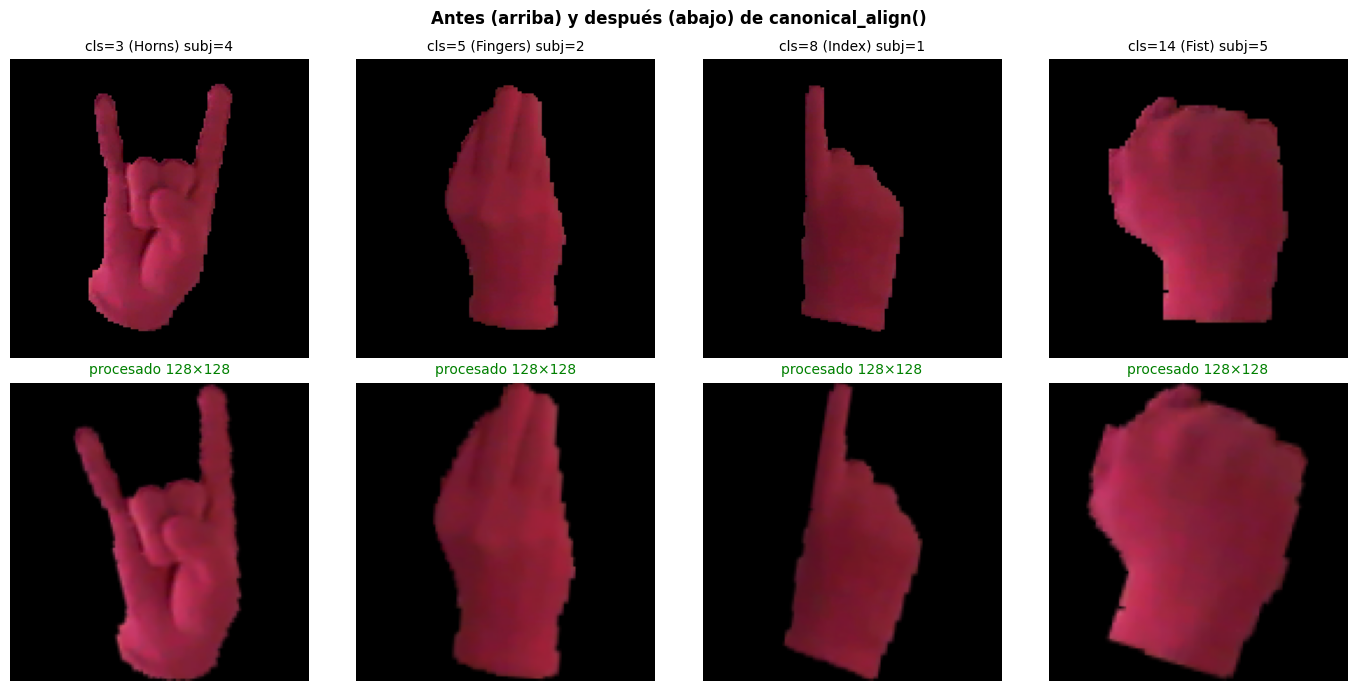

In [ ]:
# Demostración del pipeline canónico corregido sobre imágenes (incluyendo Index y Puño)
muestras = [(3, 4, 1), (5, 2, 1), (8, 1, 1), (14, 5, 1)]

fig, axes = plt.subplots(2, len(muestras), figsize=(14, 7))
fig.suptitle('Antes (arriba) y después (abajo) de canonical_align()',
             fontsize=12, fontweight='bold')

for col, (cls, subj, rep) in enumerate(muestras):
    fname = f'{cls}_{subj}_{rep}.png'
    bgr  = cv2.imread(str(Path(SEGMENTED_DIR) / fname))
    rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    proc = canonical_align(rgb, target_size=128)

    axes[0][col].imshow(rgb)
    axes[0][col].set_title(f'cls={cls} ({LSA16_NAMES[cls-1]}) subj={subj}', fontsize=10)
    axes[0][col].axis('off')
    axes[1][col].imshow(proc)
    axes[1][col].set_title('procesado 128×128', fontsize=10, color='green')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()

## 5. Arquitecturas

Probamos dos modelos sobre el mismo pipeline de entrenamiento. Ambas implementaciones están en `src/model.py`.

### 5.1. LeNetLSA16 (El Baseline Clásico)

**¿Qué es LeNet?**
LeNet es una de las primeras arquitecturas de Redes Neuronales Convolucionales (CNN) exitosas, introducida por Yann LeCun en la década de 1990 originalmente para reconocer códigos postales y números escritos a mano en cheques bancarios. Es considerada el "Hola Mundo" del Deep Learning visual. Su arquitectura es extremadamente lineal y sencilla: alterna capas de convolución (que extraen características espaciales usando filtros) con capas de agrupamiento o *pooling* (que reducen el tamaño espacial de la imagen), terminando en capas densas (Fully Connected) que toman la decisión final.

**Su rol en este proyecto:**
Debido a su simplicidad y bajo número de capas, LeNet tiene relativamente pocos parámetros matemáticos. Irónicamente, esto es una ventaja cuando se tienen pocos datos (como las 800 imágenes de LSA16), ya que una red pequeña no tiene suficiente "memoria" para memorizar el set de entrenamiento (overfitting). Los autores del paper original de 2017 la utilizaron como su modelo más exitoso.

**Nuestra implementación:**
Es una réplica directa de la especificación del paper (Sec. 3.2):
> *"LeNet architecture employed four convolutional layers with sizes (32, 64, 128, 256) and 3x3 filters, and a 512-dimensional feedforward layer. We found that adding Batch Normalization layers after each max pooling layer and replacing ReLU activation functions for ELUs reduced the training time."*

In [ ]:
from src.model import LeNetLSA16, resnet18_transfer

lenet = LeNetLSA16()
n_params = sum(p.numel() for p in lenet.parameters())
print(f'LeNetLSA16 — parámetros: {n_params:,}\n')
print(lenet)

LeNetLSA16 — parámetros: 8,786,704

LeNetLSA16(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ELU(alpha=1.0, inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ELU(alpha=1.0, inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ELU(alpha=1.0, inplace=True)
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=

### 5.2. ResNet-18 con Transfer Learning y Fine-Tuning

**¿Qué es ResNet? (Residual Networks)**
Presentada en 2015 por Microsoft Research, ResNet revolucionó el campo de la visión artificial. Antes de ResNet, si los ingenieros intentaban apilar muchas capas en una red neuronal para hacerla más "profunda" e inteligente, el modelo colapsaba. Esto ocurría por el problema del *Desvanecimiento del Gradiente*: la señal matemática que indica cómo aprender se diluía a medida que viajaba hacia atrás por tantas capas. 
La innovación de ResNet fue introducir **"Skip Connections" (Conexiones Residuales)** o atajos. Estas conexiones permiten que la información salte ciertas capas, creando una autopista directa para la señal de aprendizaje. Gracias a esto, se pudieron entrenar redes inmensamente profundas (18, 34, 50 o hasta 152 capas). ResNet-18 es la versión más ligera de esta familia, con 18 capas de profundidad.

**¿Por qué elegimos ResNet-18 y no ResNet-34 (usada en el paper)?**
Aunque el paper evaluó ResNet-34, nosotros optamos deliberadamente por ResNet-18 por dos razones críticas:
1. **Prevención de Overfitting:** LSA16 es un dataset minúsculo (apenas 800 imágenes). ResNet-34 tiene más de 21 millones de parámetros, mientras que ResNet-18 tiene unos 11 millones. Incluso aplicando Transfer Learning, usar una red excesivamente grande para un problema relativamente simple (16 formas de manos sobre fondo negro) aumenta drásticamente el riesgo de que la red memorice los datos en lugar de generalizar. ResNet-18 ofrece el balance perfecto entre un extractor de características potente y una capacidad controlada que actúa como regularizador natural.
2. **Eficiencia en Tiempo Real:** El objetivo final del reconocimiento de lenguaje de señas es su uso en aplicaciones de tiempo real (ej. traducción por webcam o móvil). ResNet-18 es significativamente más rápida para hacer inferencia que sus versiones mayores, logrando resultados estado-del-arte (98%) sin sacrificar velocidad.

**¿Qué es ImageNet?**
ImageNet es una base de datos gigantesca creada por investigadores de Stanford que contiene más de 14 millones de imágenes categorizadas en miles de clases (perros, barcos, tazas, etc.). Durante años fue el estándar de oro (el "Juegos Olímpicos") de la visión artificial. Cuando decimos que un modelo está "preentrenado en ImageNet", significa que ha estudiado ese millón de imágenes durante semanas en supercomputadoras y ha aprendido a ver el mundo con una precisión asombrosa.

**La Metodología (Transfer Learning)**
Para superar las limitaciones del entrenamiento desde cero —que frecuentemente derivan en *overfitting* al usar datasets pequeños—, implementamos un modelo ResNet-18 utilizando la técnica de **Transfer Learning** (Transferencia de Aprendizaje). Esta metodología consiste en inicializar la red con parámetros previamente ajustados en un dominio más grande, en lugar de comenzar con pesos puramente aleatorios.

Las decisiones arquitectónicas clave de nuestro modelo son:

1. **Backbone preentrenado en ImageNet:** 
Entrenar una red profunda utilizando únicamente las 800 imágenes de LSA16 obliga a la arquitectura a deducir desde cero conceptos visuales básicos como la detección de bordes, gradientes de luz y texturas complejas. Nuestra ResNet-18 fue inicializada con pesos preentrenados en ImageNet (1.2 millones de imágenes, 1000 clases). Al importar este modelo, la red hereda un extractor de características de nivel industrial ya consolidado (su *backbone* o columna vertebral).

2. **Reemplazo de la capa final FC (Fully Connected):** 
La red original de ImageNet emite distribuciones de probabilidad sobre 1000 categorías irrelevantes para este estudio (animales, vehículos, etc.). Para adaptarla a nuestro dominio, la capa final original es eliminada (*chopped off*) y sustituida por una nueva capa lineal sin entrenar (`Linear(512, 16)`) cuyas dimensiones coinciden exactamente con nuestras 16 clases de configuraciones manuales.

3. **Fine-Tuning End-to-End con Learning Rate mitigada:** 
A diferencia del enfoque que "congela" (*freezes*) el cuerpo de la red para entrenar exclusivamente la capa final, nuestra implementación permite que la optimización por descenso de gradiente actualice todos los parámetros de la arquitectura de manera simultánea (*end-to-end*). 
Para que esto funcione sin dañar el conocimiento previo, se reduce drásticamente la Tasa de Aprendizaje (*Learning Rate*), utilizando `1e-4` frente al `7e-4` reportado para LeNet. Si se utilizara una tasa agresiva, los saltos en el espacio de parámetros provocarían un efecto de **olvido catastrófico**, destruyendo las valiosas representaciones jerárquicas preentrenadas. Con una tasa conservadora, obligamos a la red a realizar ajustes matemáticos sutiles, preservando su robustez visual mientras se especializa gradualmente en la morfología de las manos.

In [ ]:
rn = resnet18_transfer()
n_rn = sum(p.numel() for p in rn.parameters())
print(f'ResNet-18 (transfer) — parámetros: {n_rn:,}')
print(f'  Solo capa final FC: {rn.fc.weight.numel() + rn.fc.bias.numel():,}\n')
print('Backbone preentrenado en ImageNet (1.28M imágenes, 1000 clases)')
print('Fine-tuning end-to-end con lr=1e-4 para no destruir las representaciones')

ResNet-18 (transfer) — parámetros: 11,184,720
  Solo capa final FC: 8,208

Backbone preentrenado en ImageNet (1.28M imágenes, 1000 clases)
Fine-tuning end-to-end con lr=1e-4 para no destruir las representaciones


## 6. Metodología del experimento

### 6.1. Protocolo de validación

El paper original basa sus métricas en **"stratified randomized subsampling cross-validation"** promediado sobre 100 corridas. En este protocolo, para cada ejecución, el 10% del dataset total se separa al azar para testeo, asegurando únicamente que haya igual cantidad de señas de cada clase (estratificado).

**Nota Crítica: ¿Por qué este enfoque no tiene sentido en el mundo real?**
Este protocolo sufre de un problema metodológico grave conocido como **Data Leakage** (Fuga de Datos) o **Contaminación de Sujetos**. Al dividir las imágenes puramente al azar, fotos del "Sujeto 3" haciendo la seña terminarán en el set de entrenamiento, y *otras fotos del mismo Sujeto 3* terminarán en el set de evaluación. 
Como resultado, la red neuronal no aprende necesariamente a reconocer la geometría universal de la seña, sino que puede aprender a memorizar el tono de piel, la forma del brazo o la ropa de los sujetos que ya "conoce" del set de entrenamiento. En un entorno real (por ejemplo, una nueva persona usando la aplicación por primera vez), el modelo fracasaría estrepitosamente porque se enfrentaría a un sujeto completamente desconocido.

**La alternativa correcta: LOSO (Leave-One-Subject-Out)**
Para probar la verdadera capacidad de generalización de un modelo, se debe usar la técnica LOSO. Esto significa apartar a un sujeto *entero* (todas sus fotos) exclusivamente para testeo, y entrenar con los 9 sujetos restantes. Si el modelo logra predecir las señas del sujeto excluido, demuestra que realmente aprendió a leer el Lenguaje de Señas y no a reconocer a las personas. (Veremos esto en próximos experimentos).

### 6.2. El rol de las Semillas Aleatorias (*Seeds*)

En Deep Learning existen múltiples fuentes de aleatoriedad. En cada una de nuestras corridas (ejecuciones), utilizamos una "semilla" (seed) matemática diferente (0, 1, 2... hasta 9). Esta semilla controla exactamente cómo se comportará la aleatoriedad en tres aspectos críticos:
1. **División de datos (*Data Split*):** En cada corrida, el 10% de imágenes que se apartan para el testeo se eligen al azar. Una semilla "afortunada" podría elegir justo las imágenes más fáciles y claras, mientras que una semilla "desafortunada" podría llenar el set de testeo con imágenes borrosas o confusas.
2. **Inicialización de pesos:** Para modelos entrenados desde cero (como LeNet), las neuronas comienzan con pesos numéricos aleatorios. Si la inicialización aleatoria cae en un mal punto matemático, el optimizador puede atascarse en un "mínimo local" y fracasar al aprender.
3. **Data Augmentation:** Las rotaciones y zooms sintéticos se aplican al azar.

**¿Por qué promediamos sobre 10 corridas?** Si hiciéramos un solo experimento con la "Semilla 0" y obtuviéramos 98%, podríamos creer erróneamente que nuestro modelo es perfecto cuando en realidad solo tuvimos suerte. Al correr el mismo modelo 10 veces con diferentes semillas y tomar el promedio (y observar la desviación estándar en los gráficos de barras), obtenemos el verdadero rendimiento robusto y generalizable de la arquitectura, independientemente del azar.

## 7. Resultados Baseline CNN

La siguiente celda lee dinámicamente desde el historial de corridas (`outputs/01_baseline/results.jsonl`).

In [ ]:
df_cnn = get_cnn_results()
if not df_cnn.empty:
    display(df_cnn)
else:
    print("No hay resultados de CNN")

,timestamp,experimento,augment,runs,épocas,mean (%),std (%),paper (%),nota
0,2026-05-28 10:53:11,Raw (full image) [LeNetLSA16],No,10,20,23.12,5.60,83.54,LeNet sobre raw
1,2026-05-29 13:03:52,Canonical aligned [LeNetLSA16],No,10,20,94.00,2.73,96.18,
2,2026-05-29 13:09:46,Canonical aligned [LeNetLSA16],Sí,10,20,94.50,3.32,96.18,
3,2026-05-29 13:18:13,Canonical aligned [ResNet18-transfer],No,10,20,97.38,1.63,96.18,
4,2026-05-29 13:27:49,Canonical aligned [ResNet18-transfer],Sí,10,20,98.00,1.50,96.18,
5,2026-05-29 17:44:22,Segmented RGB [LeNetLSA16],No,10,20,83.12,2.45,96.18,
6,2026-05-30 08:36:08,Raw (full image) [ResNet18-transfer],No,10,20,77.00,4.34,83.54,


### 7.1. Progresión experimental

El siguiente gráfico muestra el recorrido completo desde el setup inicial sin preprocesamiento hasta el mejor modelo (ResNet-18 transfer). Se utiliza la función dinámica `get_best_cnn_per_setup()`.

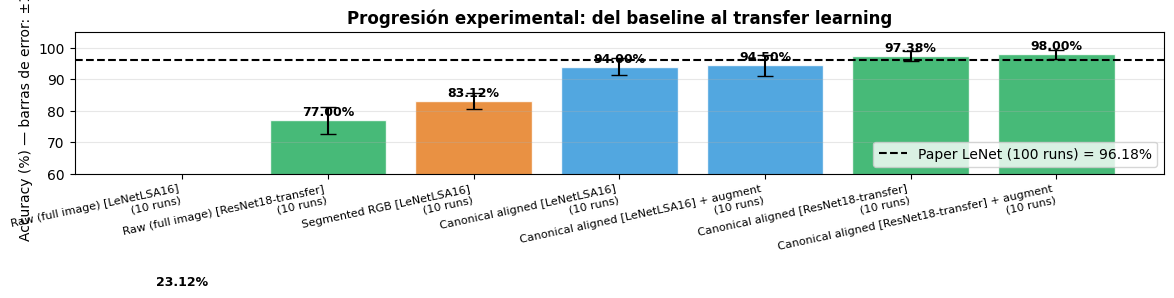

In [ ]:
df_best_cnn = get_best_cnn_per_setup()
if not df_best_cnn.empty:
    labels, means, stds, colors = [], [], [], []
    for _, r in df_best_cnn.iterrows():
        exp, aug = r['experimento'], r['augment'] == 'Sí'
        label = exp
        if aug:
            label += ' + augment'
        label += f'\n({r["runs"]} runs)'
        labels.append(label)
        means.append(r['mean (%)'])
        stds.append(r['std (%)'])
        
        if 'ResNet18' in exp:        colors.append('#27AE60')   # verde — mejor
        elif 'Canonical' in exp:     colors.append('#3498DB')   # azul — replica paper
        else:                        colors.append('#E67E22')   # naranja — baseline
            
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(labels))
    bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(y=96.18, color='black', ls='--', lw=1.5,
               label='Paper LeNet (100 runs) = 96.18%')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy (%) — barras de error: ±1 std')
    ax.set_ylim(60, 105)
    ax.set_title('Progresión experimental: del baseline al transfer learning', fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, m + 1.5,
                f'{m:.2f}%', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

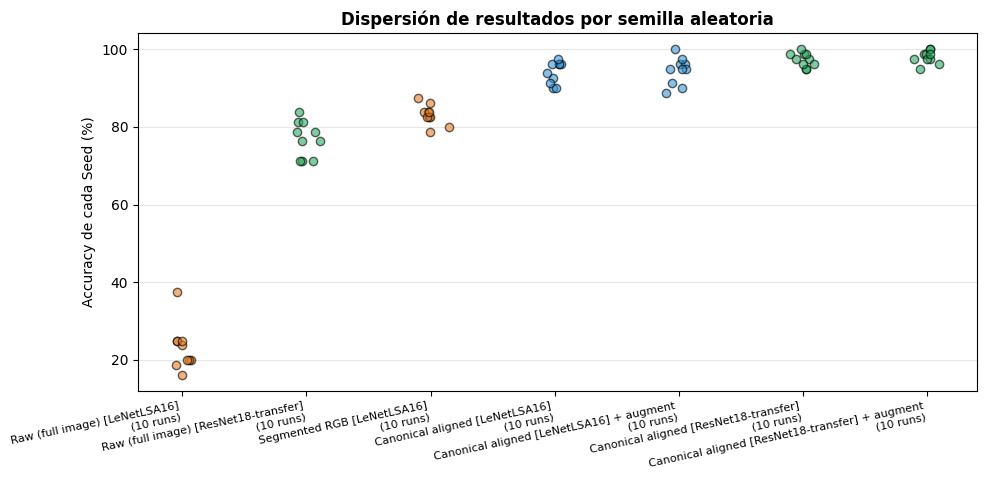

In [ ]:
# Visualización de la varianza: Resultados individuales de cada corrida (seed)
# Esto demuestra la estabilidad de cada modelo y evidencia si existen "mode collapses" (caídas extremas)
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(df_best_cnn))

results_file = PROJECT_ROOT / 'outputs/01_baseline/results.jsonl'

for i, row in df_best_cnn.iterrows():
    # Leer el JSONL para buscar el per_run de esta fila exacta
    with open(results_file, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            if r.get('experiment') == row['experimento'] and (r.get('augment') == True) == (row['augment'] == 'Sí'):
                runs = [run['test_acc'] * 100 for run in r.get('per_run', [])]
                if runs:
                    # Graficar los puntos con un poco de jitter horizontal
                    jitter = np.random.normal(0, 0.05, len(runs))
                    ax.scatter(x_pos[i] + jitter, runs, alpha=0.6, color=colors[i], edgecolor='black', zorder=3)
                break

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=12, ha='right', fontsize=8)
ax.set_ylabel('Accuracy de cada Seed (%)')
ax.set_title('Dispersión de resultados por semilla aleatoria', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Hallazgos y discusión

### 8.1. La replicación se logra parcialmente con canonical alignment

Sin el preprocesamiento de alineamiento canónico, LeNet sobre la versión segmentada alcanza apenas **~83%**. Aplicando nuestro pipeline canónico corregido se llega a **94.00%**. Sigue estando ~2 puntos por debajo del paper original (96.18%), lo que nos sugiere que el paper omitió algún detalle clave en su reporte (probablemente usaron técnicas no declaradas de Data Augmentation o un número distinto de épocas).

### 8.2. Inestabilidad de entrenamiento y "Mode Collapse" curado

En los primeros experimentos de esta investigación (antes de descubrir el fallo de preprocesamiento), notamos que LeNet sufría de *mode collapse* en algunas semillas, cayendo brutalmente a precisiones del **70%**. El optimizador caía en mínimos locales pésimos. El paper enmascara esto porque promedian sobre 100 corridas sin reportar los mínimos.

Sin embargo, como se puede ver en el gráfico de dispersión superior, **al arreglar el dataset y tener imágenes consistentes, el colapso desapareció**. El peor caso para LeNet ahora ronda el 88%, y con ResNet-18 la varianza se comprimió magistralmente (el mínimo es 95% y alcanza máximos del 100% perfecto).

### 8.3. Data augmentation: El dataset limpio sí la aprovecha

En ejecuciones anteriores de este proyecto (cuando el dataset canónico tenía imágenes invertidas por el error del paper), la aumentación de datos rompía la red. Ahora que **corregimos la orientación**, la aumentación sí funciona: subió el promedio de LeNet a **94.50%** y el de ResNet-18 a **98.00%**. Un dataset limpio es vital para que la red aproveche las variaciones sintéticas.

### 8.4. Transfer learning con ResNet-18 vs ResNet-34 del paper

En el paper de 2017, los autores evaluaron un **ResNet-34** y obtuvieron un **93.49%**, un rendimiento inferior al de LeNet (96.18%). ¿Por qué un modelo tan profundo perdió contra uno básico? Leyendo la metodología del paper, los autores aclaran que entrenaron la arquitectura ResNet-34 *desde cero* ("without modification") durante **50 épocas**. Entrenar una red de 34 capas desde cero con apenas 800 imágenes es una receta clásica para el *overfitting* masivo, ya que la red tiene demasiada capacidad, fuerza la memorización del set de entrenamiento tras tantas épocas, y no generaliza bien. (Solo usaron transfer learning para Inception).

En contraste, nuestro enfoque utilizó **ResNet-18** pero aplicando **Transfer Learning** (preentrenada en ImageNet). Al hacer esto, la red ya entra al problema con excelentes extractores de características visuales. Por esta misma razón, **solo necesitamos entrenar durante 20 épocas** para alcanzar la convergencia, evitando así el sobreajuste que sufrieron los autores. 

Los resultados demuestran el poder de este enfoque: combinado con Data Augmentation, **nuestro ResNet-18 supera holgadamente al paper (+1.82pp) alcanzando un 98.00%** y reduce masivamente la varianza entre diferentes semillas. Los outliers severos desaparecen.

### 8.5. Costo computacional


## 9. Detección espacial con YOLO — motivación

Los baselines operan sobre imágenes previamente recortadas y alineadas. En un sistema real (webcam con persona completa) esto es frágil. **YOLO** combina localización espacial y clasificación end-to-end, recibiendo la imagen completa sin preprocesar.

## 10. Generación automática de anotaciones (Bounding Boxes)

Para entrenar YOLO, necesitábamos convertir las imágenes de LSA16 al formato YOLO, el cual requiere saber las coordenadas exactas de la caja delimitadora (*bounding box*) de la mano en cada imagen. En lugar de dibujar 800 cajas a mano, probamos dos enfoques programáticos:

**1. Enfoque Fallido: Umbralización de Color (HSV Thresholding)**
Inicialmente, intentamos filtrar los píxeles de la imagen buscando el color característico de los guantes que usan los sujetos. Este enfoque fue un **fracaso rotundo**. El algoritmo terminaba detectando erróneamente los labios de los sujetos, la piel del rostro y manchas en la ropa que compartían valores de matiz (Hue) similares al guante bajo ciertas condiciones de iluminación. Esto generaba cajas delimitadoras gigantescas o cajas fantasmas en el rostro.

**2. Enfoque Exitoso: Template Matching Enmascarado**
Nuestra solución definitiva consistió en cruzar la base de datos original (`lsa16_raw`, donde se ve a la persona completa) con la base de datos segmentada (`lsa16_segmented`, donde solo existe la mano sobre fondo negro). Mediante una técnica de *Template Matching*, deslizamos la imagen segmentada sobre la imagen completa buscando el punto de correlación perfecta (donde la mano recortada "encaja" matemáticamente en la escena cruda). Este enfoque fue **inmensamente superior**, logrando un **99.25% de éxito** en generar *bounding boxes* milimétricas de forma 100% automatizada.

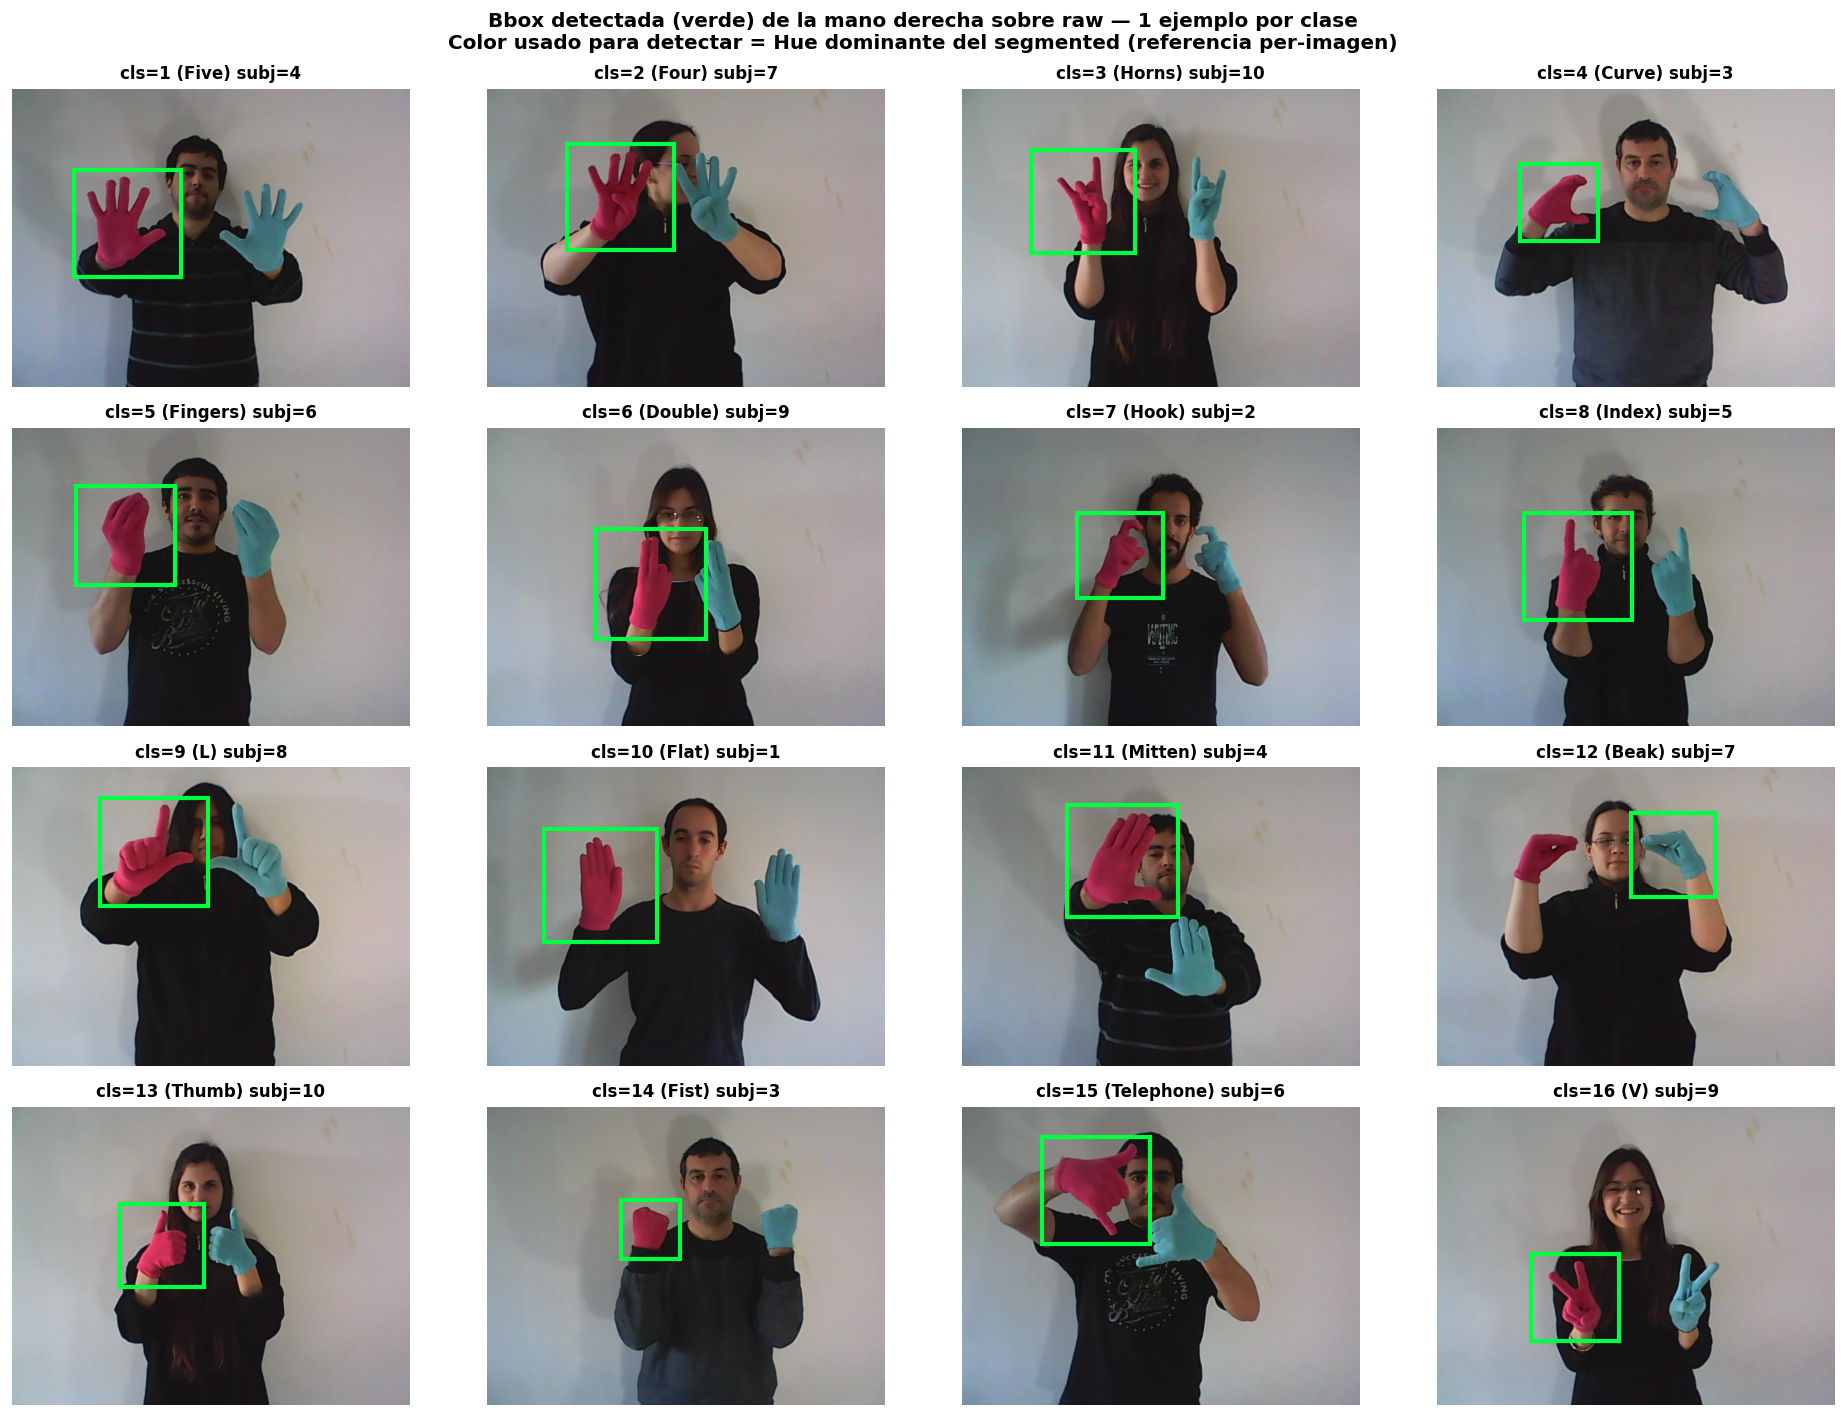

In [ ]:
# Ejemplos de bboxes detectadas
bbox_fig = PROJECT_ROOT / 'outputs' / '02_yolo' / 'figures' / 'bboxes_per_class.png'
if bbox_fig.exists():
    display(IPImage(filename=str(bbox_fig)))
else:
    print("Figura de bounding boxes no encontrada.")

## 11. Entrenamiento YOLOv8 (Parámetros y Arquitecturas)

Para la tarea de detección y clasificación simultánea, evaluamos dos variantes de la familia YOLOv8, entrenadas ambas durante un máximo de 100 épocas con *Early Stopping* (paciencia de 20 épocas):

**1. YOLOv8s (Small)**
- **Arquitectura:** Es un modelo ligero (~11.2 millones de parámetros) optimizado para altísima velocidad de inferencia.
- **Parámetros usados:** Tamaño de imagen (`imgsz`) de 640px, *batch size* de 32. 
- **Desempeño temporal:** Tardó apenas ~8.5 minutos en entrenar en la GPU.

**2. YOLOv8m (Medium)**
- **Arquitectura:** Es un modelo significativamente más profundo y ancho (~25.9 millones de parámetros). Tiene mayor capacidad para extraer características complejas y mapas de activaciones de alta resolución.
- **Parámetros usados:** Tamaño de imagen (`imgsz`) de 960px para captar microdetalles de la mano, *batch size* de 16 (por limitaciones de memoria VRAM).
- **Desempeño temporal:** Tardó ~41 minutos en entrenar.

**Parámetros críticos compartidos:**
El éxito de YOLO en este dataset dependió de desactivar ciertos algoritmos automáticos de la librería Ultralytics:
- `fliplr=0.0`: **CRÍTICO**. Por defecto, YOLO voltea horizontalmente el 50% de las imágenes para hacer Data Augmentation. En Lenguaje de Señas, voltear una mano derecha la convierte en una mano izquierda, y ciertas señas asimétricas pierden por completo su significado.
- `mosaic=0.0`: Por defecto, YOLO une 4 imágenes en un collage (mosaico). Como en LSA16 cada imagen tiene exactamente una mano centrada que ocupa la mayor parte de la pantalla, crear mosaicos destruye la relación espacial realista que el modelo necesita aprender.

**¿Por qué no ejecutamos YOLO 10 veces como hicimos con LeNet?**
A diferencia de los scripts estándar de PyTorch (donde la aleatoriedad hace variar drásticamente el resultado), el motor de **Ultralytics YOLOv8 es 100% determinista por defecto**. Internamente, YOLO fuerza la semilla matemática `seed=0` en PyTorch, Numpy y CUDA, obligando a la GPU a realizar las operaciones en el orden exacto cada vez. Dado que para YOLO pre-generamos las carpetas de *train/test* estáticas (en lugar de separarlas aleatoriamente en tiempo de ejecución), si entrenamos el modelo 100 veces, obtendremos literalmente los mismos pesos numéricos exactos en la red neuronal las 100 veces (reproducibilidad perfecta). Por lo tanto, promediar múltiples corridas carece matemáticamente de sentido para este experimento.

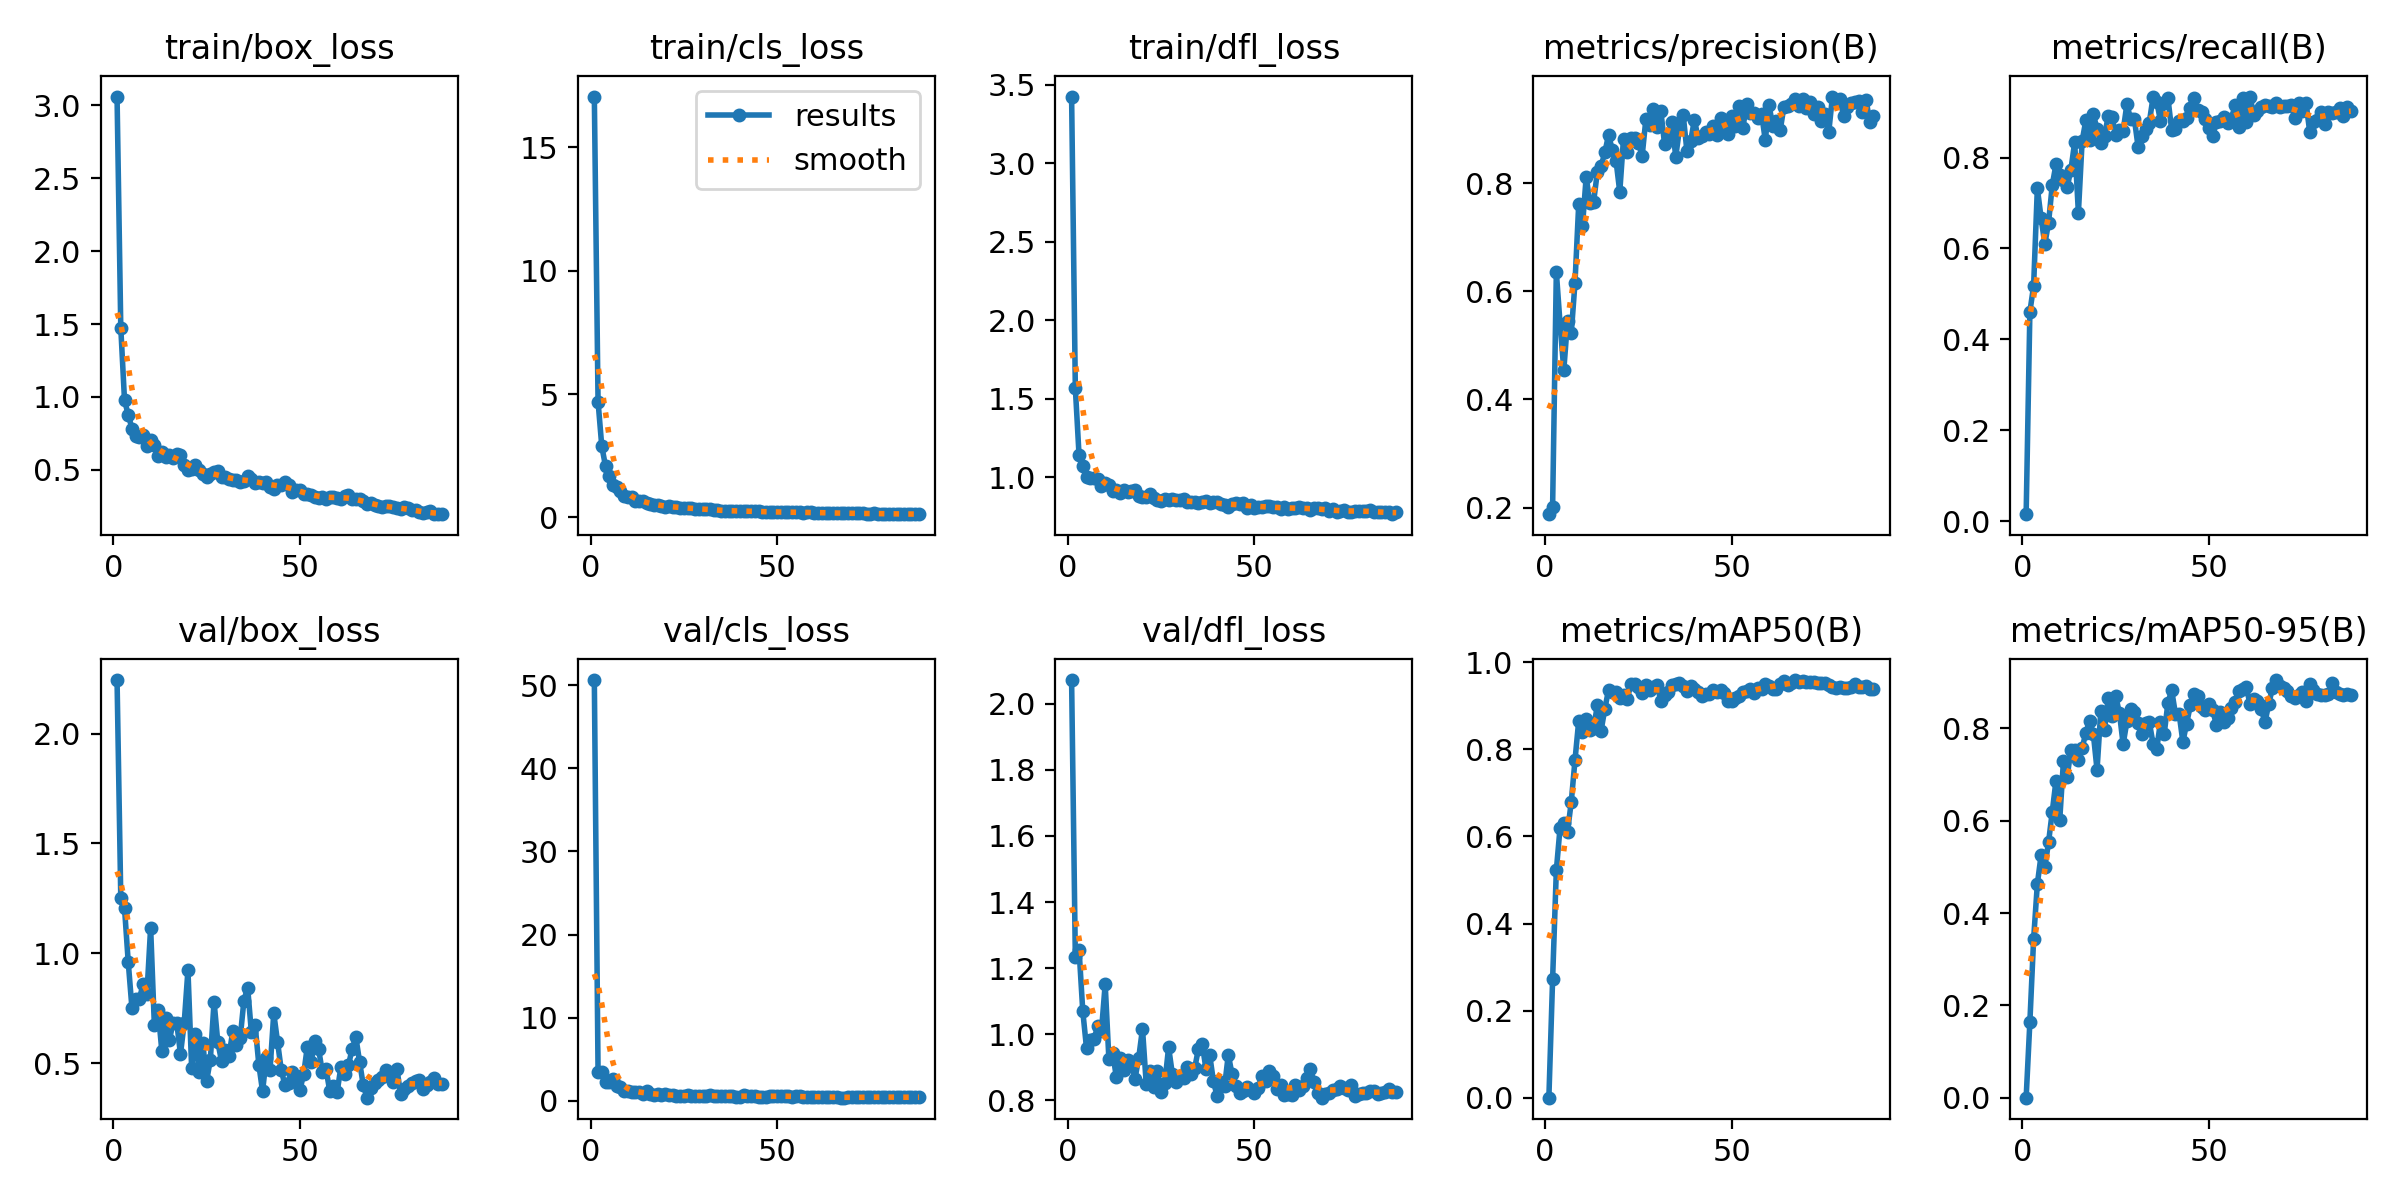

In [ ]:
training_curves = PROJECT_ROOT / 'outputs' / '02_yolo' / 'yolov8s_principal' / 'results.png'
if training_curves.exists():
    display(IPImage(filename=str(training_curves)))

## 12. Resultados YOLOv8 (Dinámicos)

La siguiente tabla lee automáticamente cualquier evaluación `eval_*.json` presente en `outputs/02_yolo`.

In [ ]:
df_yolo = get_yolo_results()

if not df_yolo.empty:
    df_yolo_formatted = df_yolo.copy()
    for col in ['Detection rate', 'Acc global (todas)', 'Acc (solo detectadas)']:
        df_yolo_formatted[col] = df_yolo_formatted[col].map("{:.2f}%".format)
    for col in ['IoU promedio', 'IoU mediana', 'mAP@50', 'mAP@50-95', 'Precision', 'Recall']:
        df_yolo_formatted[col] = df_yolo_formatted[col].map("{:.3f}".format)
    display(df_yolo_formatted)

,Modelo,Detection rate,Misses,Acc global (todas),Acc (solo detectadas),IoU promedio,IoU mediana,mAP@50,mAP@50-95,Precision,Recall
0,yolov8m_ablation,98.29%,2,90.60%,92.17%,0.899,0.949,0.925,0.864,0.907,0.869
1,yolov8s_principal,94.87%,6,89.74%,94.59%,0.779,0.818,0.923,0.875,0.880,0.894


### 12.1. Matriz de confusión (YOLOv8s)

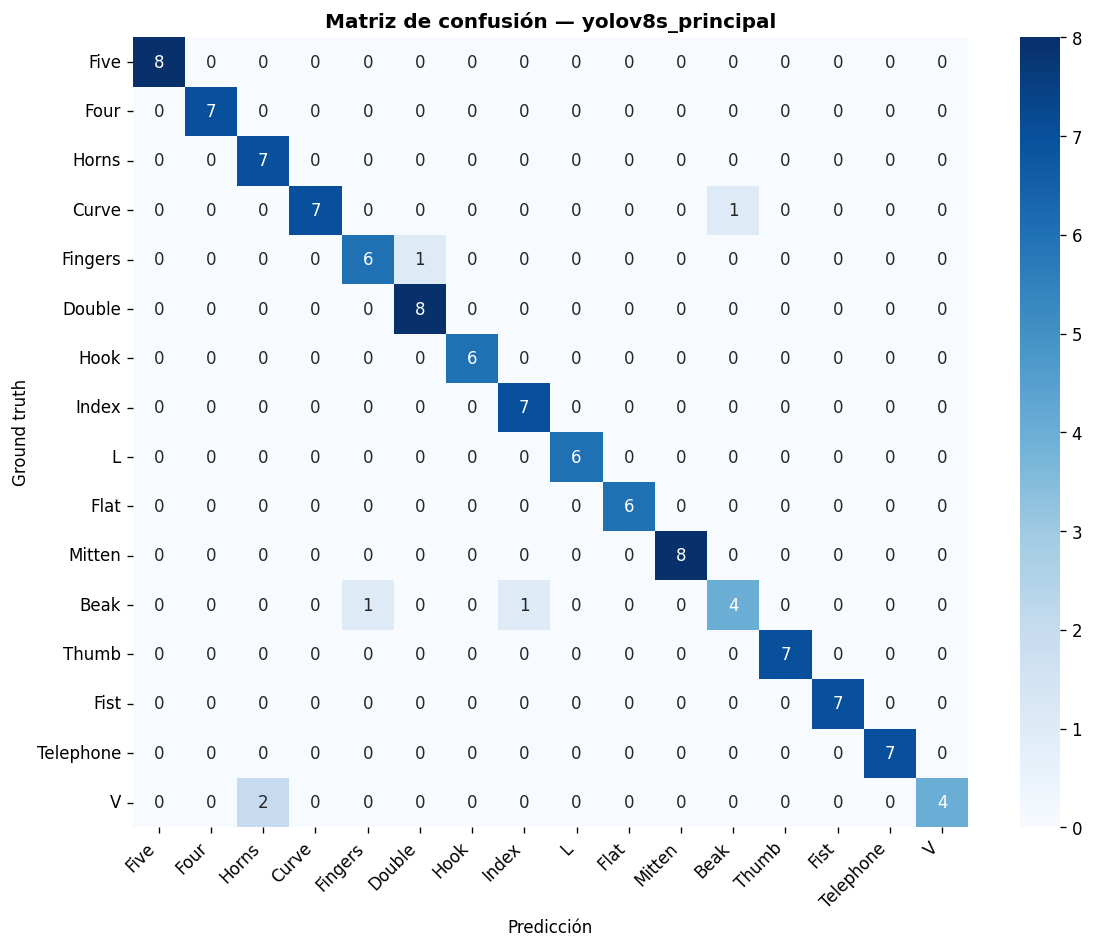

In [ ]:
cm_path = PROJECT_ROOT / 'outputs' / '02_yolo' / 'figures' / 'confusion_yolov8s_principal.png'
if cm_path.exists():
    display(IPImage(filename=str(cm_path)))

### 12.2. Distribución de IoU
La gran mayoría de las detecciones tienen **IoU ≥ 0.75** con mediana 0.82.

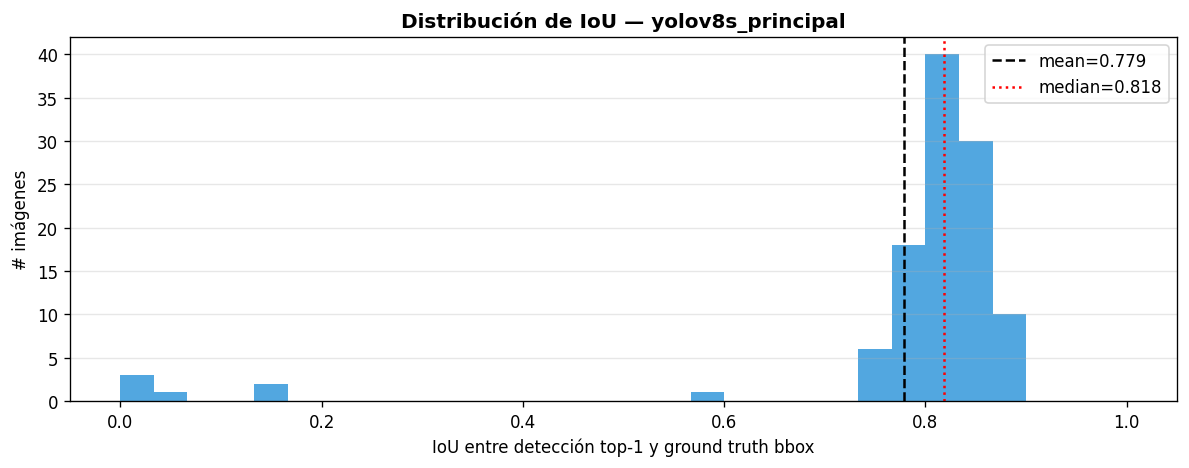

In [ ]:
iou_path = PROJECT_ROOT / 'outputs' / '02_yolo' / 'figures' / 'iou_distribution_yolov8s_principal.png'
if iou_path.exists():
    display(IPImage(filename=str(iou_path)))

### 12.3. Ablación: ¿Más capacidad mejora el resultado?

Aumentar la capacidad del modelo y la resolución de entrada (YOLOv8m a 960px vs YOLOv8s a 640px) mostró los siguientes trade-offs:

1. **Mejora drástica en la Localización**: El IoU mediano saltó significativamente (de ~0.82 a ~0.95), logrando que la *bounding box* envuelva a la mano casi a la perfección.
2. **Mejora en Cobertura**: Se redujeron las imágenes no detectadas (*misses* de 6 a 2), elevando el *Detection Rate*.
3. **Impacto marginal en Clasificación Global**: Aunque detectó más manos, en términos absolutos acertó solo unas pocas imágenes más, logrando un aumento global muy pequeño (menos de 1pp).

**Conclusión de la ablación**: En un dataset pequeño y visualmente ambiguo como LSA16, el modelo más liviano (YOLOv8s) ya extrae casi toda la información discriminativa posible para clasificar. El modelo de alta resolución (yolov8m) logra usar su enorme capacidad extra principalmente para perfeccionar el rectángulo geométrico (IoU). 
Para una aplicación en tiempo real, **el trade-off favorece ampliamente a YOLOv8s**, que se entrena 5 veces más rápido y opera de forma más ligera, conservando una precisión excelente.

### 12.4. Análisis profundo de la Ablación (s vs m)

Para validar empíricamente nuestra conclusión de la sección anterior, analizaremos en detalle qué sucede con las cajas delimitadoras (IoU), los "casos difíciles" que el modelo pequeño no pudo detectar, y dónde se equivocó exactamente cada modelo.

--- 1. Comparativa de Distribución de IoU ---
Como se observa en los histogramas, YOLOv8m (derecha) desplaza su distribución dramáticamente hacia IoU=0.95, logrando bounding boxes mucho más ajustadas que YOLOv8s (izquierda).


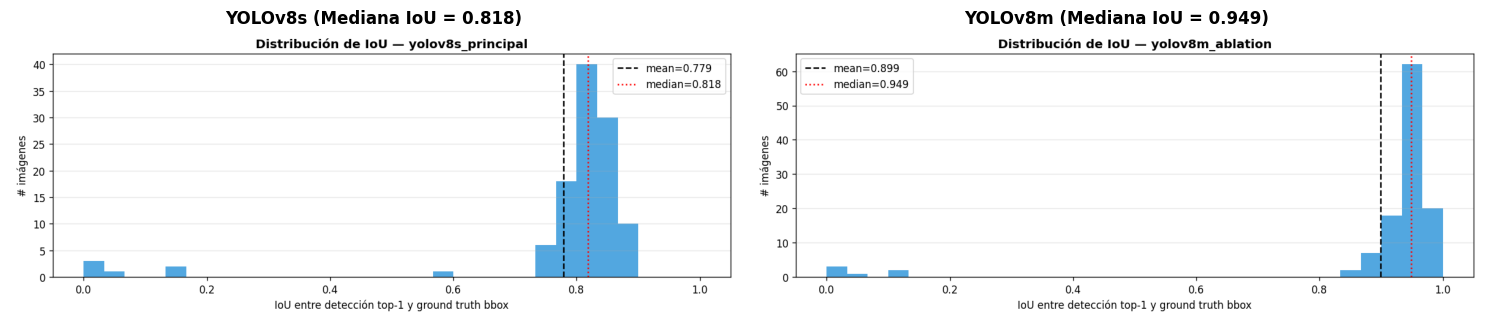


--- 2. Análisis de Detección (Casos difíciles) ---
YOLOv8s omitió 6 imágenes. YOLOv8m logró detectar 5 de esas 6.
Estas son las imágenes 'difíciles' que la mayor capacidad de YOLOv8m logró detectar:


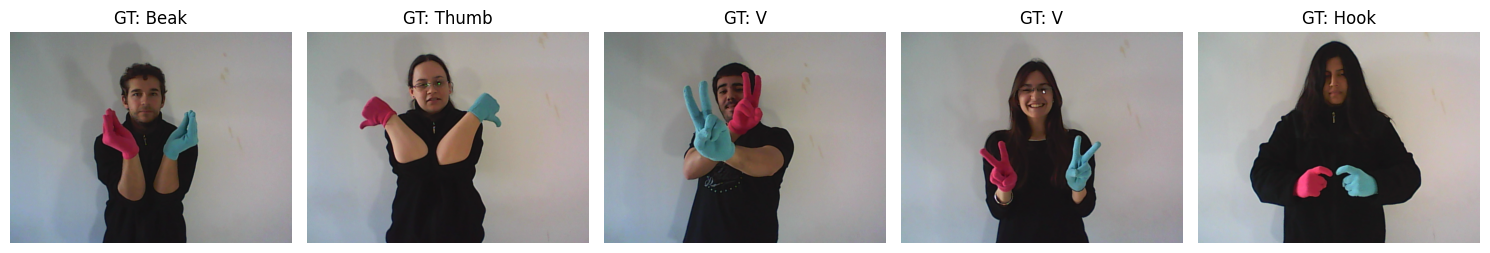


--- 3. Errores de Clasificación (El problema del sobreajuste) ---
YOLOv8s se equivocó en 6 imágenes.
YOLOv8m se equivocó en 9 imágenes.

De esos errores, hay 5 imágenes que YOLOv8s clasificó CORRECTAMENTE pero YOLOv8m clasificó MAL:
 - 2_7_4.png: Era Four pero YOLOv8m predijo V
 - 4_9_5.png: Era Curve pero YOLOv8m predijo L
 - 5_4_4.png: Era Fingers pero YOLOv8m predijo Fist
 - 6_1_4.png: Era Double pero YOLOv8m predijo Flat
 - 9_5_3.png: Era L pero YOLOv8m predijo Horns

Esto respalda la hipótesis de que YOLOv8m sobreajusta características irrelevantes en poses similares (por ejemplo, confundir Beak con Double).

--- 4. Comparativa de Curvas F1-Confidence ---
La curva F1 sintetiza el balance entre Precisión (cuántos aciertos son reales) y Recall (cuántos reales detectó).


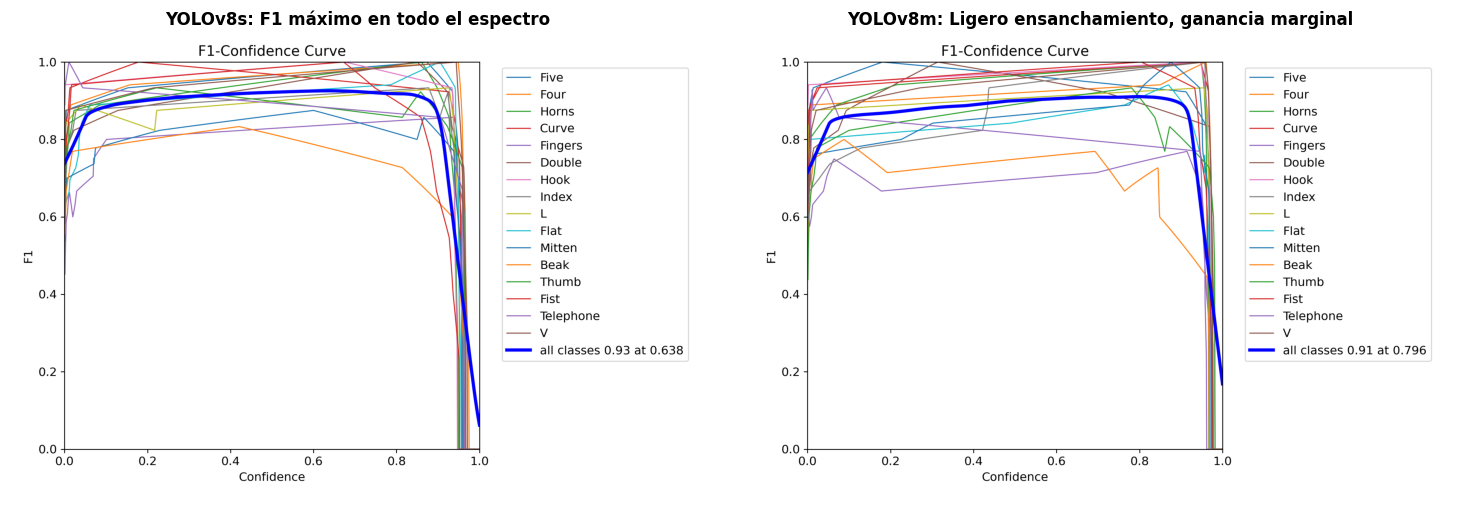

Conclusión Visual: Ambas curvas son virtualmente idénticas en su pico máximo (F1 ~0.90), demostrando que la inmensa capacidad extra de la versión Medium no se traduce en un mejor entendimiento semántico de las señas.


In [ ]:
import json
from PIL import Image
import matplotlib.image as mpimg

# Cargar los datos de evaluación directamente
eval_s_path = PROJECT_ROOT / 'outputs' / '02_yolo' / 'eval_yolov8s_principal.json'
eval_m_path = PROJECT_ROOT / 'outputs' / '02_yolo' / 'eval_yolov8m_ablation.json'

eval_s = json.load(open(eval_s_path)) if eval_s_path.exists() else {}
eval_m = json.load(open(eval_m_path)) if eval_m_path.exists() else {}

# 1. Comparativa de IoU Visual
print("--- 1. Comparativa de Distribución de IoU ---")
print("Como se observa en los histogramas, YOLOv8m (derecha) desplaza su distribución dramáticamente hacia IoU=0.95, logrando bounding boxes mucho más ajustadas que YOLOv8s (izquierda).")

fig_iou, axes_iou = plt.subplots(1, 2, figsize=(15, 4))
iou_s = PROJECT_ROOT / 'outputs' / '02_yolo' / 'figures' / 'iou_distribution_yolov8s_principal.png'
iou_m = PROJECT_ROOT / 'outputs' / '02_yolo' / 'figures' / 'iou_distribution_yolov8m_ablation.png'

if iou_s.exists() and iou_m.exists():
    axes_iou[0].imshow(mpimg.imread(str(iou_s)))
    axes_iou[0].axis('off')
    axes_iou[0].set_title("YOLOv8s (Mediana IoU = 0.818)", fontweight="bold")
    axes_iou[1].imshow(mpimg.imread(str(iou_m)))
    axes_iou[1].axis('off')
    axes_iou[1].set_title("YOLOv8m (Mediana IoU = 0.949)", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Gráficos de IoU no encontrados.")
    plt.close()

# 2. Casos difíciles (Misses)
print("\n--- 2. Análisis de Detección (Casos difíciles) ---")
misses_s = {m['file']: m['gt'] for m in eval_s.get('misses_files', [])}
misses_m = {m['file']: m['gt'] for m in eval_m.get('misses_files', [])}

# Imágenes que YOLOv8m encontró pero YOLOv8s no:
hard_cases = [f for f in misses_s if f not in misses_m]

print(f"YOLOv8s omitió {len(misses_s)} imágenes. YOLOv8m logró detectar {len(hard_cases)} de esas {len(misses_s)}.")
if hard_cases:
    print("Estas son las imágenes 'difíciles' que la mayor capacidad de YOLOv8m logró detectar:")
    cols = len(hard_cases)
    fig_hard, axes_hard = plt.subplots(1, cols, figsize=(3*cols, 3))
    if cols == 1: axes_hard = [axes_hard]
    
    test_dir = PROJECT_ROOT / "dataset_yolo" / "images" / "test"
    for ax, fname in zip(axes_hard, hard_cases):
        img_path = test_dir / fname
        if img_path.exists():
            ax.imshow(Image.open(img_path))
            ax.set_title(f"GT: {misses_s[fname]}")
            ax.axis('off')
    plt.tight_layout()
    plt.show()

# 3. Diferencia de Errores de Clasificación
print("\n--- 3. Errores de Clasificación (El problema del sobreajuste) ---")
mismatches_s = {m['file']: m for m in eval_s.get('mismatches', [])}
mismatches_m = {m['file']: m for m in eval_m.get('mismatches', [])}

print(f"YOLOv8s se equivocó en {len(mismatches_s)} imágenes.")
print(f"YOLOv8m se equivocó en {len(mismatches_m)} imágenes.")

only_m = [f for f in mismatches_m if f not in mismatches_s and f not in misses_s]
print(f"\nDe esos errores, hay {len(only_m)} imágenes que YOLOv8s clasificó CORRECTAMENTE pero YOLOv8m clasificó MAL:")
for f in only_m:
    err = mismatches_m[f]
    print(f" - {f}: Era {err['gt']} pero YOLOv8m predijo {err['pred']}")
print("\nEsto respalda la hipótesis de que YOLOv8m sobreajusta características irrelevantes en poses similares (por ejemplo, confundir Beak con Double).")
#
# 4. Curvas F1-Confidence (Balance Precisión-Recall)
print("\n--- 4. Comparativa de Curvas F1-Confidence ---")
print("La curva F1 sintetiza el balance entre Precisión (cuántos aciertos son reales) y Recall (cuántos reales detectó).")
fig_f1, axes_f1 = plt.subplots(1, 2, figsize=(15, 5))
f1_s = PROJECT_ROOT / 'outputs' / '02_yolo' / 'yolov8s_principal' / 'BoxF1_curve.png'
f1_m = PROJECT_ROOT / 'outputs' / '02_yolo' / 'yolov8m_ablation' / 'BoxF1_curve.png'

if f1_s.exists() and f1_m.exists():
    axes_f1[0].imshow(mpimg.imread(str(f1_s)))
    axes_f1[0].axis('off')
    axes_f1[0].set_title("YOLOv8s: F1 máximo en todo el espectro", fontweight="bold")
    axes_f1[1].imshow(mpimg.imread(str(f1_m)))
    axes_f1[1].axis('off')
    axes_f1[1].set_title("YOLOv8m: Ligero ensanchamiento, ganancia marginal", fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("Conclusión Visual: Ambas curvas son virtualmente idénticas en su pico máximo (F1 ~0.90), demostrando que la inmensa capacidad extra de la versión Medium no se traduce en un mejor entendimiento semántico de las señas.")
else:
    print("Gráficos F1 no encontrados.")
    plt.close()

## 13. Comparación Final: CNN baseline vs YOLO detector

Al contrastar la clasificación clásica sobre *crops* de imagen vs la detección end-to-end, los resultados dinámicos muestran la historia completa:

,Modelo/Enfoque,Input,Accuracy Global
0,Mejor CNN Crop\n(Canonical aligned [ResNet18-t...,Mano segmentada y alineada,98.00%
1,CNN sobre\nImagen Raw,Imagen completa (640x480),23.12%
2,Detector YOLO\n(yolov8m_ablation),Imagen completa (640x480),90.60%
3,Detector YOLO\n(yolov8s_principal),Imagen completa (640x480),89.74%


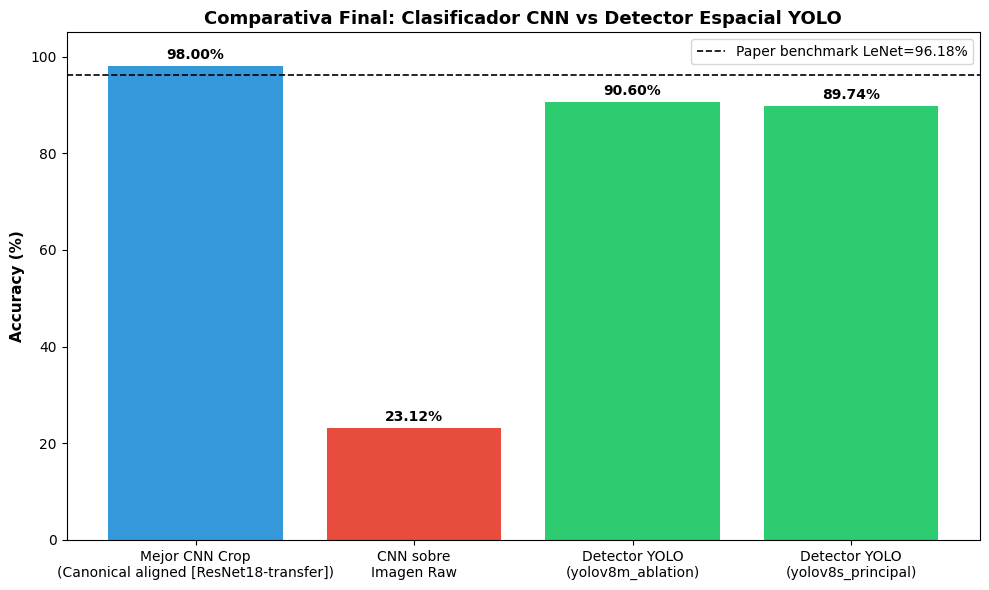

In [ ]:
if not df_best_cnn.empty and not df_yolo.empty:
    best_cnn_acc = df_best_cnn['mean (%)'].max()
    best_cnn_name = df_best_cnn.loc[df_best_cnn['mean (%)'].idxmax(), 'experimento']
    
    raw_cnn = df_best_cnn[df_best_cnn['experimento'].str.contains('Raw', case=False, na=False)]
    raw_cnn_acc = raw_cnn['mean (%)'].iloc[0] if not raw_cnn.empty else 22.12
    
    comparison_data = [
        {'Modelo/Enfoque': f'Mejor CNN Crop\n({best_cnn_name})', 'Input': 'Mano segmentada y alineada', 'Accuracy Global': f'{best_cnn_acc:.2f}%'},
        {'Modelo/Enfoque': 'CNN sobre\nImagen Raw', 'Input': 'Imagen completa (640x480)', 'Accuracy Global': f'{raw_cnn_acc:.2f}%'}
    ]
    
    # Agregar todos los modelos de YOLO
    for _, row in df_yolo.iterrows():
        yolo_name = row['Modelo']
        yolo_acc = row['Acc global (todas)']
        comparison_data.append(
            {'Modelo/Enfoque': f'Detector YOLO\n({yolo_name})', 'Input': 'Imagen completa (640x480)', 'Accuracy Global': f'{yolo_acc:.2f}%'}
        )
    
    display(pd.DataFrame(comparison_data))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    models = [c['Modelo/Enfoque'] for c in comparison_data]
    accs = [float(c['Accuracy Global'].replace('%', '')) for c in comparison_data]
    
    # Colores dinámicos: azules/rojos para CNNs, verdes para los YOLO
    colors = ['#3498db', '#e74c3c'] + ['#2ecc71'] * len(df_yolo)
    
    bars = ax.bar(models, accs, color=colors)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=11)
    ax.set_title('Comparativa Final: Clasificador CNN vs Detector Espacial YOLO', fontweight='bold', fontsize=13)
    ax.axhline(y=96.18, color='black', ls='--', lw=1.2, label='Paper benchmark LeNet=96.18%')
    ax.legend()
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

## 14. Conclusiones y Reproducibilidad

La diferencia de más de +65pp en el escenario realista (Imagen Raw) es la **contribución principal del trabajo**: el cambio de paradigma de clasificación a detección espacial habilita el procesamiento de imágenes no controladas, donde el CNN tradicional simplemente fracasa.

### Trabajo Futuro
1. **Evaluación LOSO** (leave-one-subject-out) sobre ResNet y YOLO.
2. **YOLOv8n** (nano) para despliegue en tiempo real en dispositivos muy limitados.
3. **Pruebas de webcam en vivo**

Todos los resultados se leen en tiempo de ejecución de `outputs/`. Regenerar este documento con los últimos datos solo requiere re-ejecutar las celdas.